# Optimización de rutas con A* bidireccional

**Objetivo:** encontrar rutas de menor tiempo entre paradas importantes de San José mediante A* bidireccional y comprobar el resultado con Dijkstra.

El proceso tiene cuatro etapas: 
1. Preparar la red vial
2. Identificar paradas relevantes
3. Resolver tres pares origen–destino 
4. Evaluar las rutas. 

Los tiempos de este avance representan condiciones de **flujo libre** (sin congestión vehicular) calculadas con longitudes y velocidades límite.

## 1. Configuración y datos reproducibles

La lógica del modelo se encuentra en el paquete `rutas_gam`. Y se utilizan dos archivos fijos para que los resultados puedan se reproducidos:

- `red_san_jose.graphml`: red vial dirigida descargada de OpenStreetMap (OSM).
- `paradas_importantes.csv`: 20 paradas seleccionadas con población del INEC y destinos estratégicos de OSM.

El script `scripts/generar_datos_osm.py` permite reconstruir la tabla de paradas. Vincula la densidad distrital del INEC con los límites administrativos de OSM mediante provincia, cantón y distrito; luego cuenta destinos cercanos y conserva las paradas de mayor importancia.

In [ ]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from rutas_gam import (
    agregar_tiempos, astar_bidireccional, calcular_importancia,
    cargar_grafo, cargar_paradas, dijkstra, evaluar_rutas,
    graficar_importancia, graficar_metricas, graficar_red_y_paradas,
    graficar_rutas, preparar_paradas, ruta_por_puntos, usar_nombres_visuales,
)

RAIZ = Path.cwd()
DATOS = RAIZ / "datos"
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(exist_ok=True)

print("Paquetes cargados correctamente.")

Paquetes cargados correctamente.


## 2. De la red vial a un costo de viaje

La red se representa como un grafo dirigido: las intersecciones son nodos y cada tramo transitable es un arco. Al ser dirigido, un arco $i\to j$ no implica que también exista $j\to i$; así se respetan calles de un solo sentido.

* OSM almacena en `length` la longitud del arco en metros y puede incluir la etiqueta `maxspeed`, que indica el **límite de velocidad legal registrado para ese tramo**, no la velocidad observada de los vehículos. <br>
* El paquete convierte valores de `mph` a `km/h` y toma un valor utilizable cuando OSM guarda varias alternativas.
* Si no hay un valor de `maxspeed`, se asigna una velocidad según `highway`, la clase de vía. Por ejemplo, 60 km/h para una vía primaria, 50 para una secundaria y 30 para una residencial. Estas imputaciones se basan en límites conservadores del artículo 98 de la Ley de Tránsito de Costa Rica.

El peso de cada arco es su tiempo estimado en minutos:

$$t_{ij}=\frac{d_{ij}}{v_{ij}}\left(\frac{60\ \text{min}}{1000\ \text{m}}\right)=\frac{d_{ij}}{v_{ij}}(0.06)$$

Donde $d_{ij}$ está en metros y $v_{ij}$ en km/h. Por ejemplo, recorrer 500 m a 50 km/h produce un peso de $500/50\times0.06=0.6$ minutos. A* minimiza la suma de estos pesos, no la distancia geométrica.

In [2]:
grafo = agregar_tiempos(cargar_grafo(DATOS / "red_san_jose.graphml"))
print(f"Nodos viales: {grafo.number_of_nodes():,}")
print(f"Arcos dirigidos: {grafo.number_of_edges():,}")

fuentes = pd.Series(
    [datos["speed_source"] for _, _, _, datos in grafo.edges(keys=True, data=True)]
).value_counts().rename_axis("Fuente de velocidad").reset_index(name="Arcos")
fuentes["Porcentaje %"] = fuentes["Arcos"] / fuentes["Arcos"].sum() * 100
display(fuentes.round(1))

Nodos viales: 5,975
Arcos dirigidos: 14,452


,Fuente de velocidad,Arcos,Porcentaje %
0,Imputada,12291,85.0
1,OSM,2161,15.0


## 3. ¿Cómo se eligen las paradas importantes?

Para cada parada candidata de OSM se reúnen dos señales distintas:

1. **Densidad poblacional ($DP_i$):** densidad del distrito tomada directamente de las estimaciones distritales 2022 del INEC. La parada recibe el valor del distrito que contiene su ubicación.
2. **Destinos estratégicos ($DE_i$):** cantidad de hospitales, clínicas, escuelas, colegios, universidades, municipalidades, tribunales y mercados registrados en OSM dentro de 500 metros. Este radio aproxima una distancia caminable.

Como ambas variables usan escalas diferentes, primero se aplica normalización mínimo–máximo sobre todas las paradas candidatas:

$$X_i^{norm}=\frac{X_i-X_{min}}{X_{max}-X_{min}}$$

Así cada señal queda entre 0 y 1. Luego se calcula:

$$w_i=0.6\,DP_i^{norm}+0.4\,DE_i^{norm}$$

El 60 % da mayor importancia a la población potencialmente atendida y el 40 % reconoce la atracción de destinos esenciales. El generador ordena todas las candidatas por $w_i$ y guarda las 20 mayores. Este peso solo selecciona paradas: **no se suma al tiempo de los arcos ni modifica la ruta encontrada por A***.

In [3]:
paradas = cargar_paradas(DATOS / "paradas_importantes.csv")
paradas = preparar_paradas(grafo, calcular_importancia(paradas))
paradas_presentacion = usar_nombres_visuales(paradas)
display(paradas_presentacion[[
    "Nombre", "Distrito", "Densidad poblacional",
    "Destinos estratégicos", "Índice de importancia"
]].round(3))
assert len(paradas) >= 20

,Nombre,Distrito,Densidad poblacional,Destinos estratégicos,Índice de importancia
0,Parada de Autobus.,León XIII,23915.278,3,0.633
1,Terminal León XIII,León XIII,23915.278,0,0.600
2,Torre Mercedes,Hospital,7716.566,31,0.504
3,Ruta Sabana Cementerio,Hospital,7716.566,31,0.504
4,Ruta Cementerio Sabana,Hospital,7716.566,31,0.504
5,Ruta Cementerio Sabana,Hospital,7716.566,31,0.504
6,Hospital de Niños - Paseo Colón,Hospital,7716.566,31,0.504
7,Torre Mercedes,Hospital,7716.566,31,0.504
8,Ruta Sabana Cementerio,Hospital,7716.566,30,0.493
9,Paseo Colon,Hospital,7716.566,30,0.493


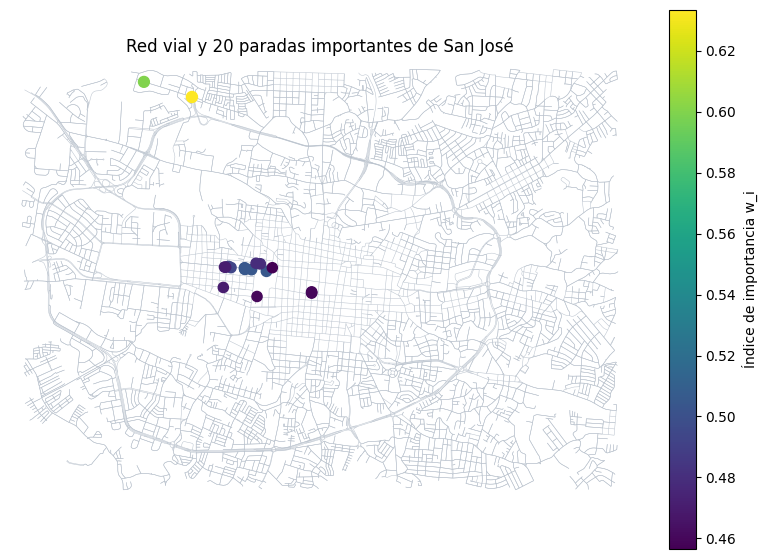

In [4]:
graficar_red_y_paradas(grafo, paradas, FIGURAS / "01_red_paradas_importantes.png")
plt.show()

**Cómo leer el mapa:** cada punto es una parada y su tamaño y color representan $w_i$. Un punto destacado puede deberse a una densidad distrital alta, a muchos destinos cercanos o a ambas condiciones. La concentración espacial también revela una limitación: al escoger únicamente las 20 puntuaciones mayores, varias paradas pueden quedar agrupadas en el centro urbano.

> En una futura entrega se debe tomar en cuenta incorporar un mecanismo que seleccione paradas menos agrupadas.

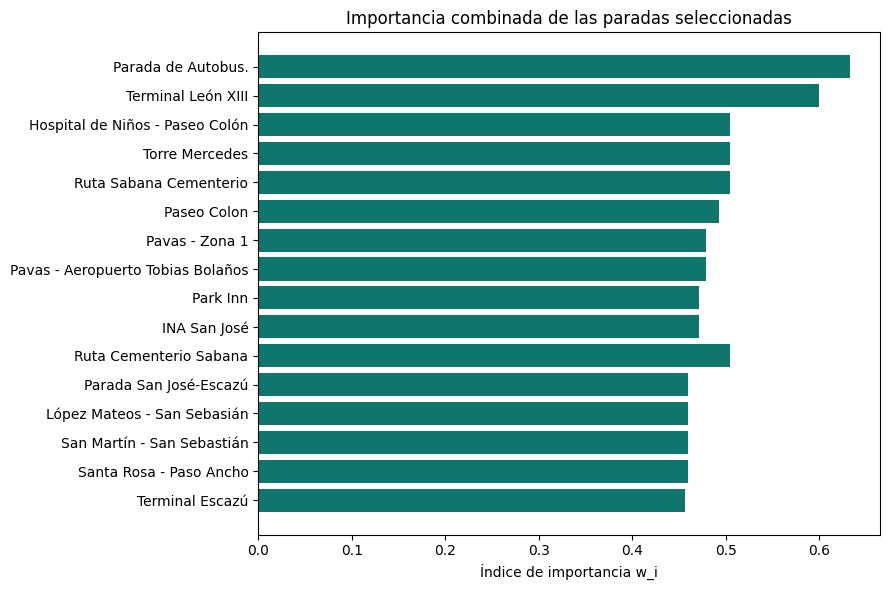

In [5]:
graficar_importancia(paradas, FIGURAS / "02_importancia_paradas.png")
plt.show()

**Cómo leer el gráfico:** una barra más larga indica mayor prioridad para considerar la parada como origen o destino. Los empates son esperables cuando varias plataformas pertenecen al mismo distrito y comparten los mismos destinos dentro de 500 metros. El índice no afirma cuántos pasajeros utiliza cada parada; funciona como una aproximación mientras no se disponga de demanda observada.

## 4. ¿Cómo funciona A* bidireccional?

A* decide qué nodo explorar usando $f(n)=g(n)+h(n)$. El término $g(n)$ es el tiempo acumulado desde el inicio y $h(n)$ estima el tiempo que falta. En este proyecto:

$$h(n)=\frac{\text{distancia geodésica entre }n\text{ y la meta}}{v_{max}}$$

La distancia geodésica es la separación en línea recta sobre la superficie terrestre y $v_{max}$ es la mayor velocidad asignada en toda la red. Incluso en el mejor caso no se puede llegar más rápido que esa estimación; por eso la heurística es admisible y no elimina la ruta óptima.

La versión bidireccional mantiene dos búsquedas: una avanza desde el origen y otra desde el destino usando el grafo inverso. Cuando ambas fronteras encuentran una conexión y sus mejores alternativas pendientes ya no pueden mejorarla, el algoritmo se detiene y reconstruye el camino. Dijkstra utiliza los mismos tiempos de arco, pero sin heurística, y sirve como control: ambos deben devolver el mismo costo.

In [13]:
puntos_estudio = cargar_paradas(DATOS / "puntos_estudio.csv")
puntos_estudio = preparar_paradas(grafo, puntos_estudio)
puntos_busqueda = pd.concat([paradas, puntos_estudio], ignore_index=True)
display(usar_nombres_visuales(puntos_estudio)[["Nombre", "Sector"]])

def buscar_parada(fragmento):
    coincidencias = puntos_busqueda[
        puntos_busqueda["nombre"].str.contains(fragmento, case=False, na=False)
    ]
    return coincidencias.iloc[0]

configuraciones = [
    ("Estadio Oeste → San Pedro", "Estadio Oeste", "San Pedro - Carmiol", "Torre Mercedes"),
    ("Cuatro Reinas → Paso Ancho", "Terminal Cuatro Reinas", "Parada El Caracol", "Hospital de Niños"),
    ("Hatillo → Curridabat", "Periférica Hatillo", "Plaza del Sol", "Paseo Colon"),
]

KeyError: "['Sector'] not in index"

## 5. Pares de estudio, ruta óptima y referencia base

Los tres pares se fijaron manualmente con paradas reales de OSM ubicadas en lados opuestos de Circunvalación. Estadio Oeste–San Pedro cruza de oeste a este; Cuatro Reinas–Paso Ancho, de norte a sur; y Hatillo–Curridabat, de suroeste a este. Los seis extremos se guardan en `puntos_estudio.csv` para que su ubicación sea reproducible y se conectan al nodo vial más cercano.

Estos puntos se mantienen separados de las 20 paradas ordenadas por importancia: el índice $w_i$ responde a densidad y destinos cercanos, mientras la elección de estos pares responde a cobertura geográfica.

Para cada par se comparan dos recorridos:

- **Ruta optimizada:** A* minimiza el tiempo estimado de origen a destino.
- **Ruta base reproducible:** pasa por el punto intermedio indicado y minimiza distancia en cada segmento. Representa una alternativa de comparación, no una ruta oficial ni el recorrido actual de un autobús.

La tabla también muestra Dijkstra. Si su costo coincide con A*, se confirma que la búsqueda bidireccional encontró el óptimo bajo los pesos definidos.

In [7]:
filas = []
rutas_para_grafico = []
for numero, (nombre, texto_origen, texto_destino, texto_intermedio) in enumerate(configuraciones):
    origen = buscar_parada(texto_origen)
    destino = buscar_parada(texto_destino)
    intermedio = buscar_parada(texto_intermedio)
    resultado_astar = astar_bidireccional(grafo, origen.node_id, destino.node_id)
    resultado_dijkstra = dijkstra(grafo, origen.node_id, destino.node_id)
    assert math.isclose(resultado_astar["costo"], resultado_dijkstra["costo"], rel_tol=1e-9)
    assert all(grafo.has_edge(u, v) for u, v in zip(resultado_astar["ruta"][:-1], resultado_astar["ruta"][1:]))
    ruta_base = ruta_por_puntos(
        grafo, [origen.node_id, intermedio.node_id, destino.node_id], peso="length"
    )
    metricas = evaluar_rutas(
        grafo, resultado_astar["ruta"], ruta_base,
        resultado_astar["nodos_explorados"], semilla=42 + numero,
    )
    fila = metricas.to_dict()
    fila.update({
        "par": nombre,
        "costo_dijkstra_min": resultado_dijkstra["costo"],
        "NE_dijkstra": resultado_dijkstra["nodos_explorados"],
        "ejecucion_astar_ms": resultado_astar["milisegundos"],
        "ejecucion_dijkstra_ms": resultado_dijkstra["milisegundos"],
        "punto_base": intermedio["nombre"],
    })
    filas.append(fila)
    rutas_para_grafico.append({"nombre": nombre, "ruta": resultado_astar["ruta"]})

resultados = pd.DataFrame(filas)
resultados.to_csv("resultados_rutas.csv", index=False)

resultados_presentacion = usar_nombres_visuales(resultados)
display(resultados_presentacion.round(2))

,Distancia óptima (km),Tiempo óptimo (min),Tiempo base (min),RT %,RV %,IC %,NE,Par,Costo Dijkstra (min),NE Dijkstra,Ejecución A* (ms),Ejecución Dijkstra (ms),Punto base
0,9.81,9.96,11.11,10.35,9.16,84.2,4235.0,Estadio Oeste → San Pedro,9.96,4877,50.00,25.33,Torre Mercedes
1,5.56,8.22,8.59,4.32,4.34,84.0,3094.0,Cuatro Reinas → Paso Ancho,8.22,3245,47.69,15.76,Hospital de Niños - Paseo Colón
2,9.19,8.98,12.45,27.86,27.72,82.2,3197.0,Hatillo → Curridabat,8.98,4105,39.29,20.68,Paseo Colon


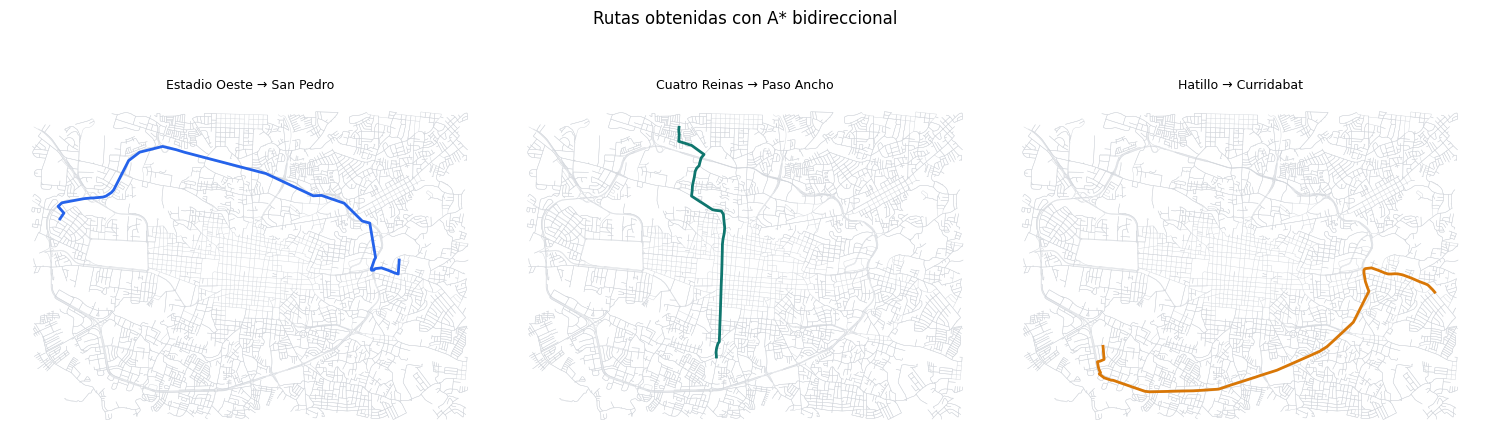

In [8]:
graficar_rutas(grafo, rutas_para_grafico, FIGURAS / "03_rutas_astar.png")
plt.show()

**Cómo leer los mapas:** la línea coloreada sigue la secuencia de arcos dirigida elegida por A*. El trazado puede desviarse de la línea recta por calles de un solo sentido o porque una vía algo más larga permite mayor velocidad. La igualdad numérica con Dijkstra confirma el costo óptimo de los tres recorridos; no confirma todavía tiempos reales de hora pico.

## 6. Métricas de éxito y análisis de sensibilidad

Las métricas responden preguntas diferentes:

- **Reducción de tiempo (RT):** ¿cuánto menor es el tiempo determinista de A* respecto a la ruta base? $RT=(T_{base}-T_{A*})/T_{base}\times100$.
- **Reducción de variabilidad (RV):** ¿cuánto disminuye la desviación estándar simulada? $RV=(1-s_{A*}/s_{base})\times100$.
- **Índice de confiabilidad (IC):** ¿en qué porcentaje de simulaciones el tiempo de la ruta optimizada no supera el 115 % de su media?
- **Nodos explorados (NE):** ¿cuántos nodos tuvo que cerrar el algoritmo? Un valor menor implica menos trabajo de búsqueda, aunque el tiempo de ejecución también depende del equipo.

Para RV e IC se generan 1 000 escenarios con semilla fija. Cada tiempo de arco recibe una variación lognormal según su clase vial y cada escenario incluye un factor general que representa condiciones compartidas, como lluvia o mayor tránsito. La simulación ocurre **después** de seleccionar la ruta: no añade una penalización $\lambda\sigma$ al costo y no pretende sustituir datos observados de hora pico.

,Par,Tiempo óptimo (min),Tiempo base (min),RT %,RV %,IC %,NE,NE Dijkstra
0,Estadio Oeste → San Pedro,9.96,11.11,10.35,9.16,84.2,4235.0,4877
1,Cuatro Reinas → Paso Ancho,8.22,8.59,4.32,4.34,84.0,3094.0,3245
2,Hatillo → Curridabat,8.98,12.45,27.86,27.72,82.2,3197.0,4105


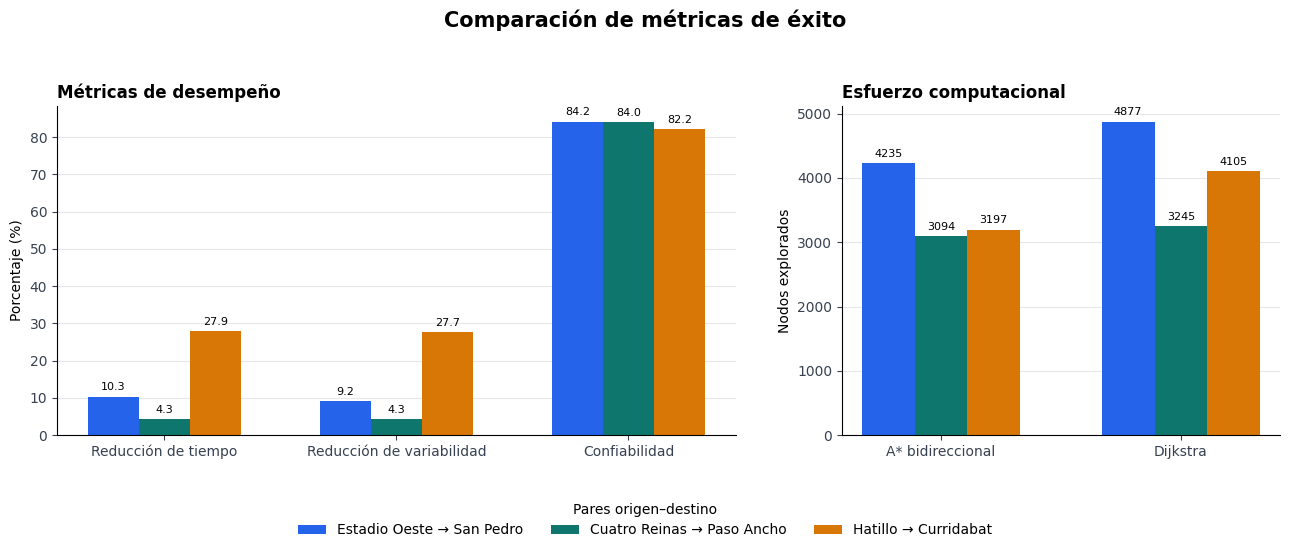

In [9]:
display(resultados_presentacion[[
    "Par", "Tiempo óptimo (min)", "Tiempo base (min)",
    "RT %", "RV %", "IC %", "NE", "NE Dijkstra"
]].round(2))
graficar_metricas(resultados, FIGURAS / "04_metricas_exito.png")
plt.show()

## 7. Lectura final y conclusiones

En el gráfico, cada grupo corresponde a una métrica y cada color conserva el mismo par origen–destino. RT y RV comparan la ruta optimizada con su referencia; IC describe únicamente la ruta optimizada. El panel de nodos explorados permite comparar el esfuerzo de A* con Dijkstra sin mezclar cantidades con porcentajes.

- El proceso separa dos decisiones: $w_i$ identifica paradas importantes y los tiempos $t_{ij}$ determinan el camino mínimo.
- A* bidireccional aprovecha una heurística admisible y respeta la dirección de los arcos. Dijkstra confirma el mismo costo óptimo en los tres pares.
- RT se interpreta frente a una referencia reproducible. RV e IC son resultados de sensibilidad con semilla fija, no evidencia de congestión observada.
- Las velocidades límite describen flujo libre y la densidad es constante dentro de cada distrito. La cobertura de destinos depende de OSM.
- La siguiente etapa debe incorporar observaciones reales de 6:00–8:00 a. m., demanda por parada y recorridos oficiales para reemplazar las referencias metodológicas.